In [ ]:
import mip
from pathlib import Path

PROJECT_ROOT = Path(mip.__file__).parent.parent


In [1]:
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statistics
from sklearn.cluster import DBSCAN, KMeans


In [2]:
import os
import osmnx as ox

GRAPH_PATH = PROJECT_ROOT / "cache/ukraine_major_roads.graphml"
os.makedirs("cache", exist_ok=True)
ox.settings.max_query_area_size = 50_000_000_000

if os.path.exists(GRAPH_PATH):
    print("Loading cached graph...")
    G_raw = ox.load_graphml(GRAPH_PATH)
else:
    print("Downloading graph...")
    G_raw = ox.graph_from_place(
        "Ukraine",
        network_type="drive",
        custom_filter='["highway"~"motorway|trunk|primary|secondary"]',
    )
    G_raw = ox.add_edge_speeds(G_raw)
    G_raw = ox.add_edge_travel_times(G_raw)
    ox.save_graphml(G_raw, GRAPH_PATH)


Loading cached graph...


In [ ]:
# import osmnx as ox
# import networkx as nx
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors
# import statistics
# from sklearn.cluster import DBSCAN, KMeans

# # ── 1. Pull country-wide road graph ──────────────────────────────────────
# # Using major roads only (drive+trunk) to keep it manageable
# print("Pulling Ukraine country graph (major roads only)...")
# G_raw = ox.graph_from_place("Ukraine", network_type="drive",
#                              custom_filter='["highway"~"motorway|trunk|primary"]')


In [3]:

G_raw = ox.add_edge_speeds(G_raw)

for u, v, data in G_raw.edges(data=True):
    if data.get("speed_kph", 0) == 0 or "speed_kph" not in data:
        highway = data.get("highway", "primary")
        if isinstance(highway, list): highway = highway[0]
        defaults = {"motorway":110,"trunk":90,"primary":80}
        data["speed_kph"] = defaults.get(highway, 80)

G_raw = ox.add_edge_travel_times(G_raw)
G_raw = ox.convert.to_undirected(G_raw)
G_raw = G_raw.subgraph(max(nx.connected_components(G_raw), key=len)).copy()
print(f"Raw graph: {G_raw.number_of_nodes()} nodes, {G_raw.number_of_edges()} edges")

# ── 2. Coarsen aggressively ───────────────────────────────────────────────
def coarsen_graph(G, eps_deg):
    from sklearn.cluster import DBSCAN
    node_ids = list(G.nodes())
    coords = np.array([[G.nodes[n]['y'], G.nodes[n]['x']] for n in node_ids])
    labels = DBSCAN(eps=eps_deg, min_samples=1).fit(coords).labels_
    node_to_cluster = {node_ids[i]: labels[i] for i in range(len(node_ids))}
    CG = nx.Graph()
    for cid in set(labels):
        members = [n for n, c in node_to_cluster.items() if c == cid]
        CG.add_node(cid,
            lat=np.mean([G.nodes[n]['y'] for n in members]),
            lon=np.mean([G.nodes[n]['x'] for n in members]),
            member_count=len(members))
    for u, v, data in G.edges(data=True):
        cu, cv = node_to_cluster[u], node_to_cluster[v]
        if cu == cv: continue
        t = data.get("travel_time", float("inf"))
        if CG.has_edge(cu, cv):
            if t < CG[cu][cv]["travel_time"]: CG[cu][cv]["travel_time"] = t
        else:
            CG.add_edge(cu, cv, travel_time=t)
    CG = CG.subgraph(max(nx.connected_components(CG), key=len)).copy()
    return CG

for eps in [0.1,0.15,0.2,0.24,0.25,0.3, 0.5]:
    CG = coarsen_graph(G_raw, eps)
    print(f"eps={eps}: {CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges")


Raw graph: 25048 nodes, 37956 edges
eps=0.1: 841 nodes, 1435 edges
eps=0.15: 474 nodes, 877 edges
eps=0.2: 212 nodes, 375 edges
eps=0.24: 93 nodes, 148 edges
eps=0.25: 78 nodes, 118 edges
eps=0.3: 32 nodes, 43 edges
eps=0.5: 2 nodes, 1 edges



Coarsened: 93 nodes, 148 edges
Travel time (hrs): min=0.2, mean=0.6, max=2.2

Loading ACLED...
Total violent events in Ukraine: 146600

Demand clusters (KMeans k=15):
          lat        lon  n_events  total_fatalities
0   46.748874  32.850865     13355             46558
1   47.994410  37.501397     24077             34521
3   48.904410  38.161011     15727             16511
10  48.438221  37.890931     19080             13857
4   47.545645  35.670915     10551              9303
6   50.168200  36.489131      9107              8885
11  49.619279  37.698456     13206              8600
8   47.739996  36.639645     10512              5572
13  47.417978  34.018045      6293              2550
12  46.625889  31.597243      2871              1946
14  50.449219  30.279085      1359              1803
9   50.817534  35.171222      6865               981
7   52.136621  32.506703      4462               595
2   51.676002  34.113922      8819               359
5   49.828760  25.603303       316   

/Users/sohans/Projects/CSCI617_MIO_project/ukraine-medical-logistics/.venv/lib/python3.11/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 17 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


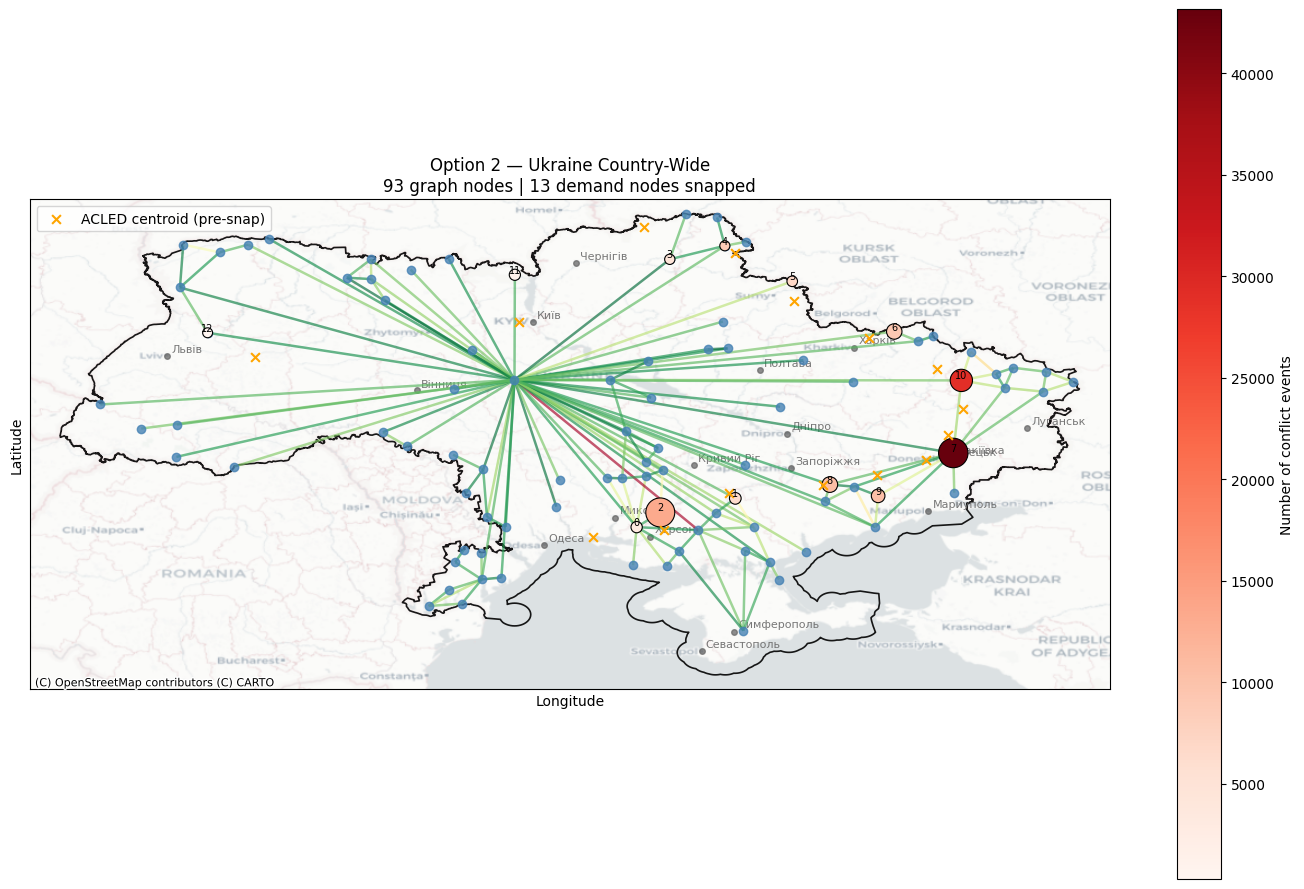

In [4]:


# Pick whichever gives ~80-150 nodes
CHOSEN_EPS = 0.24
CG = coarsen_graph(G_raw, CHOSEN_EPS)
times = [d["travel_time"] for u,v,d in CG.edges(data=True)]
print(f"\nCoarsened: {CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges")
print(f"Travel time (hrs): min={min(times)/3600:.1f}, mean={statistics.mean(times)/3600:.1f}, max={max(times)/3600:.1f}")

# ── 3. Load ACLED — full Ukraine, use KMeans for balanced demand nodes ────
print("\nLoading ACLED...")
df = pd.read_csv(PROJECT_ROOT / "data/ACLED Data_2026-03-25.csv")
df = df[
    (df["country"] == "Ukraine") &
    (df["year"] >= 2022) &
    (df["event_type"].isin(["Explosions/Remote violence","Battles","Violence against civilians"]))
]
print(f"Total violent events in Ukraine: {len(df)}")

# KMeans with fixed k — gives geographically spread demand nodes
coords_acled = df[["latitude","longitude"]].values
N_DEMAND = 15  # adjust as needed
km = KMeans(n_clusters=N_DEMAND, random_state=42, n_init=10)
km.fit(coords_acled)
df["cluster"] = km.labels_

demand_raw = (
    df.groupby("cluster")
    .agg(lat=("latitude","mean"), lon=("longitude","mean"),
         n_events=("event_type","count"), total_fatalities=("fatalities","sum"))
    .reset_index(drop=True)
)
print(f"\nDemand clusters (KMeans k={N_DEMAND}):")
print(demand_raw.sort_values("total_fatalities", ascending=False).to_string())

# ── 4. Snap to graph ──────────────────────────────────────────────────────
def snap_to_graph(CG, lat, lon):
    best_node, best_dist = None, float("inf")
    for n, data in CG.nodes(data=True):
        dist = (data["lat"] - lat)**2 + (data["lon"] - lon)**2
        if dist < best_dist:
            best_dist = dist
            best_node = n
    return best_node

demand_raw["graph_node"] = demand_raw.apply(
    lambda row: snap_to_graph(CG, row["lat"], row["lon"]), axis=1)
demand_nodes = demand_raw.groupby("graph_node").agg(
    n_events=("n_events","sum"),
    total_fatalities=("total_fatalities","sum")
).reset_index()
print(f"\nUnique demand nodes on graph: {len(demand_nodes)}")

# ── 5. Visualize on a Ukraine basemap ─────────────────────────────────────
import contextily as ctx

ukraine_shape = ox.geocode_to_gdf("Ukraine")
cities = ox.features_from_place("Ukraine", tags={"place": ["city"]}).copy()
cities = cities[cities.geometry.geom_type == "Point"].copy()
cities = cities[cities["name"].notna()].copy()
if "population" in cities.columns:
    cities["population_num"] = pd.to_numeric(cities["population"], errors="coerce")
else:
    cities["population_num"] = np.nan
cities = cities.sort_values(["population_num", "name"], ascending=[False, True])
cities = cities.drop_duplicates(subset="name").head(18)

pos = {n: (d["lon"], d["lat"]) for n, d in CG.nodes(data=True)}
edge_times = [CG[u][v]["travel_time"] for u,v in CG.edges()]
norm = mcolors.Normalize(vmin=min(edge_times), vmax=max(edge_times))
cmap = cm.RdYlGn_r

minx, miny, maxx, maxy = ukraine_shape.total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)

try:
    ctx.add_basemap(
        ax,
        crs="EPSG:4326",
        source=ctx.providers.CartoDB.Positron,
        zoom=6,
        alpha=0.8,
    )
except Exception as exc:
    print(f"Basemap unavailable, continuing without tiles: {exc}")

ukraine_shape.boundary.plot(ax=ax, color="black", linewidth=1.2, alpha=0.9, zorder=1)
cities.plot(ax=ax, color="dimgray", markersize=16, alpha=0.75, zorder=2)

for _, city in cities.iterrows():
    ax.annotate(
        city["name"],
        (city.geometry.x, city.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8,
        color="dimgray",
        alpha=0.9,
        zorder=3,
    )

edge_collection = nx.draw_networkx_edges(
    CG, pos, ax=ax,
    edge_color=[cmap(norm(t)) for t in edge_times], width=1.8, alpha=0.65,
)
edge_collection.set_zorder(4)
node_collection = nx.draw_networkx_nodes(
    CG, pos, ax=ax, node_size=36,
    node_color="steelblue", alpha=0.8,
)
node_collection.set_zorder(5)

demand_pos_x = [CG.nodes[n]["lon"] for n in demand_nodes["graph_node"]]
demand_pos_y = [CG.nodes[n]["lat"] for n in demand_nodes["graph_node"]]
sc = ax.scatter(demand_pos_x, demand_pos_y,
    s=demand_nodes["total_fatalities"] / demand_nodes["total_fatalities"].max() * 400 + 50,
    c=demand_nodes["n_events"], cmap="Reds",
    zorder=6, edgecolors="black", linewidths=0.8)

ax.scatter(demand_raw["lon"], demand_raw["lat"],
    marker="x", c="orange", s=40, zorder=7, label="ACLED centroid (pre-snap)")

for i, row in demand_nodes.iterrows():
    ax.annotate(str(i), (CG.nodes[row["graph_node"]]["lon"],
                          CG.nodes[row["graph_node"]]["lat"]),
                fontsize=7, ha="center", va="bottom", zorder=8)

ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)
ax.set_aspect("equal", adjustable="box")
plt.colorbar(sc, ax=ax, label="Number of conflict events")
ax.legend(loc="upper left")
ax.set_title(f"Option 2 — Ukraine Country-Wide\n"
             f"{CG.number_of_nodes()} graph nodes | {len(demand_nodes)} demand nodes snapped")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/option2_ukraine.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# import osmnx as ox

# # Override the max query area — send one request instead of 422
# ox.settings.max_query_area_size = 50_000_000_000

# G_raw = ox.graph_from_bbox(
#     bbox=(48.85, 48.30, 38.15, 37.40),
#     network_type="drive",
#     custom_filter='["highway"~"motorway|trunk|primary|secondary"]'
# )


/Users/sohans/Projects/CSCI617_MIO_project/ukraine-medical-logistics/.venv/lib/python3.11/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 21 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Raw graph: 45052 nodes, 67904 edges
eps=0.5: 16 nodes, 22 edges

Using eps=0.5: 16 nodes, 22 edges
Travel time (min): min=30.0, mean=74.6, max=155.5

Loading ACLED...
Conflict events in corridor: 17053
  ACLED eps=0.03: 94 clusters
  ACLED eps=0.05: 23 clusters
  ACLED eps=0.07: 5 clusters
  ACLED eps=0.1: 1 clusters

Demand clusters: 23
          lat        lon  n_events  total_fatalities
0   48.528840  37.935206     13924             10834
11  48.495814  37.960025      1768              1200
5   48.319566  37.529923       187              1017
2   48.730928  37.582000       254               335
4   48.318795  37.762270       129               245
18  48.807448  37.554426        23               210
8   48.308950  37.445933        72                81
9   48.804300  38.147400       309                39
3   48.616500  37.529200       100                32
12  48.342467  37.677892        36                19
15  48.838773  37.646236        11                17
16  48.838300  37.973000

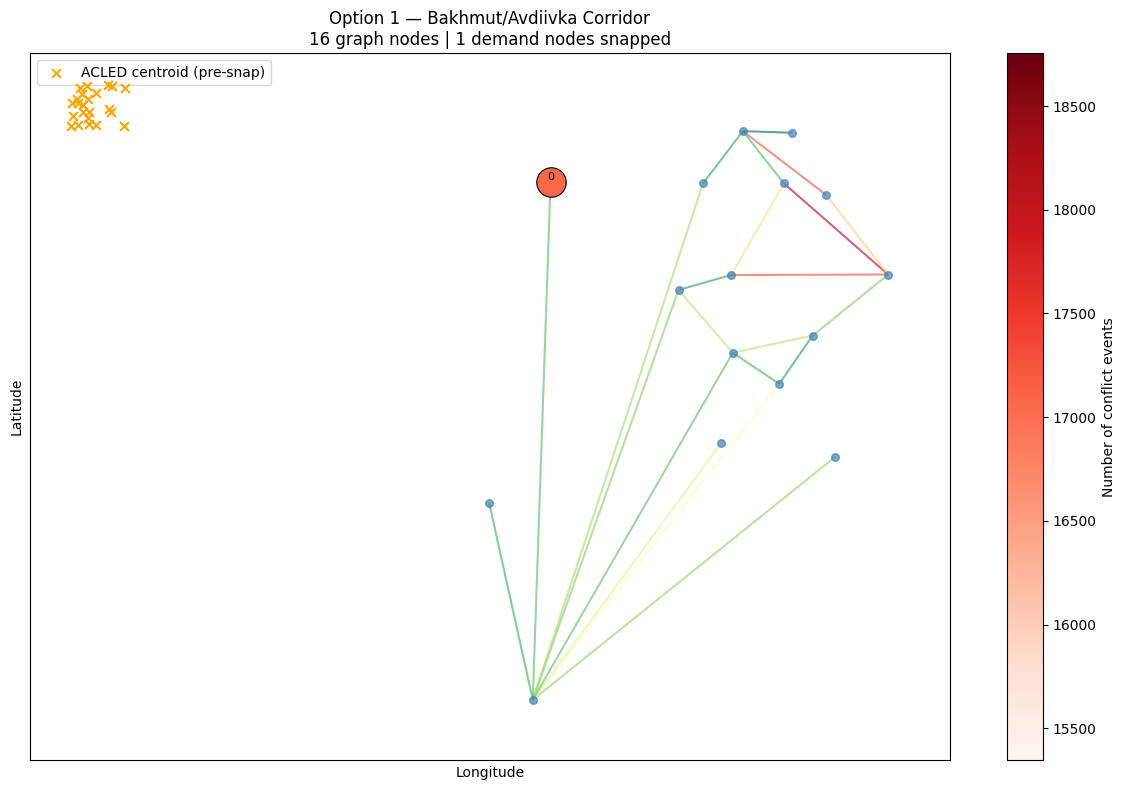

In [ ]:
# G_raw = ox.add_edge_speeds(G_raw)

# for u, v, data in G_raw.edges(data=True):
#     if data.get("speed_kph", 0) == 0 or "speed_kph" not in data:
#         highway = data.get("highway", "unclassified")
#         if isinstance(highway, list): highway = highway[0]
#         defaults = {"motorway":110,"trunk":90,"primary":80,"secondary":60,
#                     "tertiary":40,"residential":30,"unclassified":25,"track":15}
#         data["speed_kph"] = defaults.get(highway, 25)

# G_raw = ox.add_edge_travel_times(G_raw)
# G_raw = ox.convert.to_undirected(G_raw)
# G_raw = G_raw.subgraph(max(nx.connected_components(G_raw), key=len)).copy()
# print(f"Raw graph: {G_raw.number_of_nodes()} nodes, {G_raw.number_of_edges()} edges")

# # ── 2. Coarsen ────────────────────────────────────────────────────────────
# def coarsen_graph(G, eps_deg):
#     node_ids = list(G.nodes())
#     coords = np.array([[G.nodes[n]['y'], G.nodes[n]['x']] for n in node_ids])
#     labels = DBSCAN(eps=eps_deg, min_samples=1).fit(coords).labels_
#     node_to_cluster = {node_ids[i]: labels[i] for i in range(len(node_ids))}
#     CG = nx.Graph()
#     for cid in set(labels):
#         members = [n for n, c in node_to_cluster.items() if c == cid]
#         CG.add_node(cid,
#             lat=np.mean([G.nodes[n]['y'] for n in members]),
#             lon=np.mean([G.nodes[n]['x'] for n in members]),
#             member_count=len(members))
#     for u, v, data in G.edges(data=True):
#         cu, cv = node_to_cluster[u], node_to_cluster[v]
#         if cu == cv: continue
#         t = data.get("travel_time", float("inf"))
#         if CG.has_edge(cu, cv):
#             if t < CG[cu][cv]["travel_time"]: CG[cu][cv]["travel_time"] = t
#         else:
#             CG.add_edge(cu, cv, travel_time=t)
#     CG = CG.subgraph(max(nx.connected_components(CG), key=len)).copy()
#     return CG

# # Check sizes — with filtered graph these should be much smaller
# for eps in [0.5]:
#     CG = coarsen_graph(G_raw, eps)
#     print(f"eps={eps}: {CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges")

# # Set after seeing output — aim for 80-150 nodes
# CHOSEN_EPS = 0.5
# CG = coarsen_graph(G_raw, CHOSEN_EPS)
# times = [d["travel_time"] for u,v,d in CG.edges(data=True)]
# print(f"\nUsing eps={CHOSEN_EPS}: {CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges")
# print(f"Travel time (min): min={min(times)/60:.1f}, mean={statistics.mean(times)/60:.1f}, max={max(times)/60:.1f}")

# # ── 3. Load and cluster ACLED ─────────────────────────────────────────────
# print("\nLoading ACLED...")
# df = pd.read_csv(PROJECT_ROOT / "data/ACLED Data_2026-03-25.csv")
# df = df[
#     (df["country"] == "Ukraine") &
#     (df["year"] >= 2022) &
#     (df["latitude"].between(48.30, 48.85)) &
#     (df["longitude"].between(37.40, 38.15)) &
#     (df["event_type"].isin(["Explosions/Remote violence","Battles","Violence against civilians"]))
# ]
# print(f"Conflict events in corridor: {len(df)}")

# coords_acled = df[["latitude","longitude"]].values
# for eps in [0.03, 0.05, 0.07, 0.10]:
#     labels = DBSCAN(eps=eps, min_samples=3).fit(coords_acled).labels_
#     n = len(set(labels)) - (1 if -1 in labels else 0)
#     print(f"  ACLED eps={eps}: {n} clusters")

# ACLED_EPS = 0.05
# labels = DBSCAN(eps=ACLED_EPS, min_samples=3).fit(coords_acled).labels_
# df["cluster"] = labels
# demand_raw = (
#     df[df["cluster"] >= 0]
#     .groupby("cluster")
#     .agg(lat=("latitude","mean"), lon=("longitude","mean"),
#          n_events=("event_type","count"), total_fatalities=("fatalities","sum"))
#     .reset_index(drop=True)
# )
# print(f"\nDemand clusters: {len(demand_raw)}")
# print(demand_raw.sort_values("total_fatalities", ascending=False).to_string())

# # ── 4. Snap demand nodes to coarsened graph ───────────────────────────────
# def snap_to_graph(CG, lat, lon):
#     best_node, best_dist = None, float("inf")
#     for n, data in CG.nodes(data=True):
#         dist = (data["lat"] - lat)**2 + (data["lon"] - lon)**2
#         if dist < best_dist:
#             best_dist = dist
#             best_node = n
#     return best_node

# demand_raw["graph_node"] = demand_raw.apply(
#     lambda row: snap_to_graph(CG, row["lat"], row["lon"]), axis=1)
# demand_nodes = demand_raw.groupby("graph_node").agg(
#     n_events=("n_events","sum"),
#     total_fatalities=("total_fatalities","sum")
# ).reset_index()
# print(f"\nUnique demand nodes on graph: {len(demand_nodes)}")
# print(demand_nodes.to_string())

# # ── 5. Visualize ──────────────────────────────────────────────────────────
# pos = {n: (d["lon"], d["lat"]) for n, d in CG.nodes(data=True)}
# edge_times = [CG[u][v]["travel_time"] for u,v in CG.edges()]
# norm = mcolors.Normalize(vmin=min(edge_times), vmax=max(edge_times))
# cmap = cm.RdYlGn_r

# fig, ax = plt.subplots(figsize=(12, 8))
# nx.draw_networkx_edges(CG, pos, ax=ax,
#     edge_color=[cmap(norm(t)) for t in edge_times], width=1.5, alpha=0.6)
# nx.draw_networkx_nodes(CG, pos, ax=ax, node_size=30,
#     node_color="steelblue", alpha=0.7)

# # Snapped demand nodes
# demand_pos_x = [CG.nodes[n]["lon"] for n in demand_nodes["graph_node"]]
# demand_pos_y = [CG.nodes[n]["lat"] for n in demand_nodes["graph_node"]]
# sc = ax.scatter(demand_pos_x, demand_pos_y,
#     s=demand_nodes["total_fatalities"] / demand_nodes["total_fatalities"].max() * 400 + 50,
#     c=demand_nodes["n_events"], cmap="Reds",
#     zorder=5, edgecolors="black", linewidths=0.8)

# # Original ACLED centroids as X
# ax.scatter(demand_raw["lon"], demand_raw["lat"],
#     marker="x", c="orange", s=40, zorder=6, label="ACLED centroid (pre-snap)")

# for i, row in demand_nodes.iterrows():
#     ax.annotate(str(i), (CG.nodes[row["graph_node"]]["lon"],
#                           CG.nodes[row["graph_node"]]["lat"]),
#                 fontsize=8, ha="center", va="bottom", zorder=7)

# plt.colorbar(sc, ax=ax, label="Number of conflict events")
# ax.legend(loc="upper left")
# ax.set_title(f"Option 1 — Bakhmut/Avdiivka Corridor\n"
#              f"{CG.number_of_nodes()} graph nodes | {len(demand_nodes)} demand nodes snapped")
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")
# plt.tight_layout()
# plt.savefig(PROJECT_ROOT / "data/figures/option1_corridor_fixed.png", dpi=150, bbox_inches="tight")
# plt.show()


Computing betweenness centrality (may take a moment)...

aᵢ: min=4.22, mean=7.63, max=9.17
bᵢ: min=4.22, mean=7.68, max=9.21

Large hub threshold (member_count): 16.00
Large hub nodes: [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(9), np.int64(11), np.int64(12), np.int64(25), np.int64(26), np.int64(33), np.int64(36), np.int64(37), np.int64(39), np.int64(40), np.int64(41), np.int64(57), np.int64(59), np.int64(61), np.int64(63), np.int64(69), np.int64(70), np.int64(74), np.int64(75), np.int64(77), np.int64(83)]

Top 5 cheapest nodes to open (lowest aᵢ):
  Node 3: aᵢ=4.225, bᵢ=4.225, lat=49.421, lon=30.202, degree=57, centrality=0.941, members=17395, large_hub_proximity=0.000
  Node 69: aᵢ=5.92, bᵢ=5.968, lat=48.245, lon=28.289, degree=2, centrality=0.000, members=19, large_hub_proximity=0.873
  Node 57: aᵢ=5.967, bᵢ=6.059, lat=45.406, lon=28.678, degree=3, centrality=0.000, members=187, large_hub_proximity=0.676
  Node 70: aᵢ=5.971, bᵢ=6.016, lat=48.491, lon=

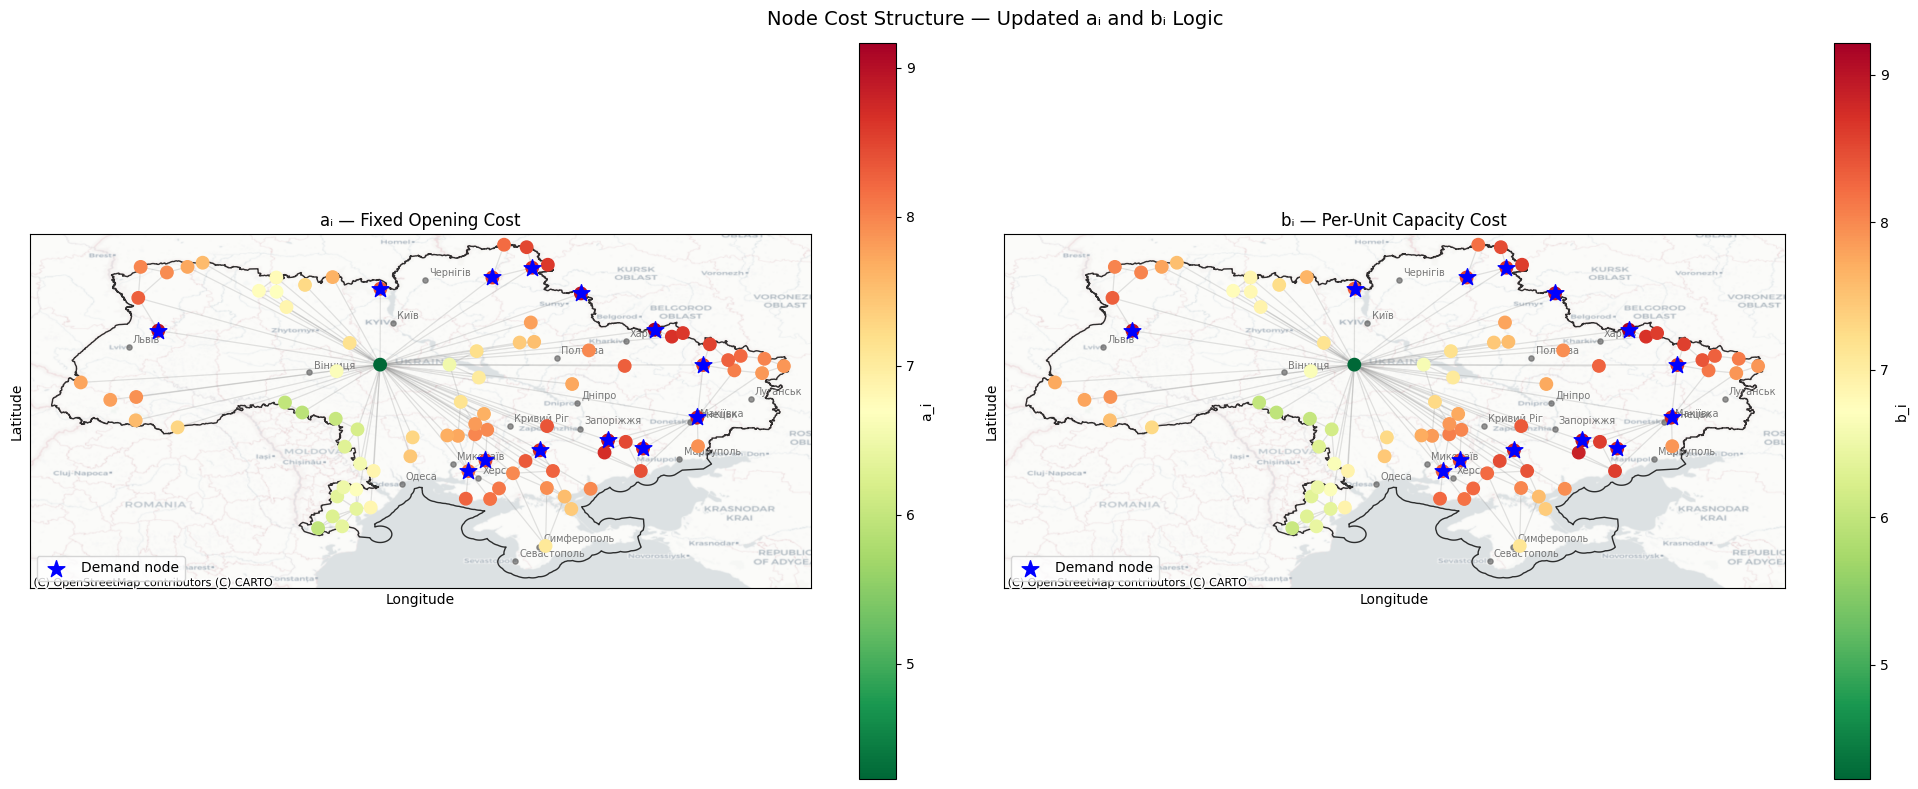

In [5]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import contextily as ctx

# Reuse the map layers from the Option 2 plot when available.
if "ukraine_shape" not in globals():
    ukraine_shape = ox.geocode_to_gdf("Ukraine")
if "cities" not in globals():
    cities = ox.features_from_place("Ukraine", tags={"place": ["city"]}).copy()
    cities = cities[cities.geometry.geom_type == "Point"].copy()
    cities = cities[cities["name"].notna()].copy()
    if "population" in cities.columns:
        cities["population_num"] = pd.to_numeric(cities["population"], errors="coerce")
    else:
        cities["population_num"] = np.nan
    cities = cities.sort_values(["population_num", "name"], ascending=[False, True])
    cities = cities.drop_duplicates(subset="name").head(18)

# ── Compute features for each node ───────────────────────────────────────
degree = dict(CG.degree())

print("Computing betweenness centrality (may take a moment)...")
centrality = nx.betweenness_centrality(CG, weight="travel_time", normalized=True)

# Closer to demand is treated as closer to the frontline.
def min_dist_to_demand(CG, node, demand_node_ids):
    node_lat = CG.nodes[node]["lat"]
    node_lon = CG.nodes[node]["lon"]
    dists = []
    for d in demand_node_ids:
        d_lat = CG.nodes[d]["lat"]
        d_lon = CG.nodes[d]["lon"]
        dists.append(((node_lat - d_lat)**2 + (node_lon - d_lon)**2)**0.5)
    return min(dists)

demand_node_ids = sorted(set(demand_nodes["graph_node"]))
dist_to_demand = {n: min_dist_to_demand(CG, n, demand_node_ids) for n in CG.nodes()}
member_count = {n: CG.nodes[n].get("member_count", 1) for n in CG.nodes()}

# Distance to larger infrastructure hubs.
# We treat the top quartile by member_count as "large hubs" and discount nodes
# that sit close to those bigger infrastructure clusters.
large_hub_threshold = np.quantile(list(member_count.values()), 0.75)
large_hub_ids = [n for n, m in member_count.items() if m >= large_hub_threshold]
if not large_hub_ids:
    large_hub_ids = list(CG.nodes())

def dist_to_large_hub(CG, node, large_hub_ids):
    node_lat = CG.nodes[node]["lat"]
    node_lon = CG.nodes[node]["lon"]
    dists = []
    for h in large_hub_ids:
        if h == node:
            continue
        h_lat = CG.nodes[h]["lat"]
        h_lon = CG.nodes[h]["lon"]
        base_dist = ((node_lat - h_lat)**2 + (node_lon - h_lon)**2)**0.5
        hub_scale = np.sqrt(CG.nodes[h].get("member_count", 1))
        dists.append(base_dist / hub_scale)
    if not dists:
        return 0.0
    return min(dists)

large_hub_dist = {n: dist_to_large_hub(CG, n, large_hub_ids) for n in CG.nodes()}

# ── Normalize each feature to [0, 1] ─────────────────────────────────────
def normalize(d):
    vals = np.array(list(d.values()), dtype=float)
    mn, mx = vals.min(), vals.max()
    if mx == mn:
        return {k: 0.5 for k in d}
    return {k: (float(v) - mn) / (mx - mn) for k, v in d.items()}

norm_degree = normalize(degree)
norm_centrality = normalize(centrality)
norm_dist = normalize(dist_to_demand)
norm_member = normalize(member_count)
norm_large_hub_dist = normalize(large_hub_dist)
frontline_proximity = {n: 1 - norm_dist[n] for n in CG.nodes()}
large_hub_proximity = {n: 1 - norm_large_hub_dist[n] for n in CG.nodes()}

# ── Compute aᵢ and bᵢ with the updated logic ──────────────────────────────
# aᵢ = fixed opening cost
#   high if: low degree (isolated, hard to supply)
#   high if: close to frontline (needs more fortification)
#   low if:  high member count (existing infrastructure)
#   low if:  close to other larger hubs (supporting infrastructure nearby)
#
# bᵢ = per-unit capacity cost
#   high if: close to frontline (capacity is expensive to maintain under fire)
#   low if:  high centrality (well-connected nodes are efficient to expand)
#   low if:  high member count (existing infrastructure)
#   low if:  close to other larger hubs (shared support / redundancy)
node_params = {}
for n in CG.nodes():
    a_raw = (
        0.3 * (1 - norm_degree[n])
      + 0.3 * frontline_proximity[n]
      + 0.2 * (1 - norm_member[n])
      + 0.2 * (1 - large_hub_proximity[n])
    )
    b_raw = (
        0.3 * frontline_proximity[n]
      + 0.25 * (1 - norm_centrality[n])
      + 0.25 * (1 - norm_member[n])
      + 0.2 * (1 - large_hub_proximity[n])
    )
    node_params[n] = {
        "a_i": round(1 + 9 * a_raw, 3),
        "b_i": round(1 + 9 * b_raw, 3),
    }

# ── Print summary ─────────────────────────────────────────────────────────
a_vals = [v["a_i"] for v in node_params.values()]
b_vals = [v["b_i"] for v in node_params.values()]
print(f"\naᵢ: min={min(a_vals):.2f}, mean={np.mean(a_vals):.2f}, max={max(a_vals):.2f}")
print(f"bᵢ: min={min(b_vals):.2f}, mean={np.mean(b_vals):.2f}, max={max(b_vals):.2f}")

sorted_by_a = sorted(node_params.items(), key=lambda x: x[1]["a_i"])
print(f"\nLarge hub threshold (member_count): {large_hub_threshold:.2f}")
print(f"Large hub nodes: {large_hub_ids}")
print("\nTop 5 cheapest nodes to open (lowest aᵢ):")
for n, p in sorted_by_a[:5]:
    print(
        f"  Node {n}: aᵢ={p['a_i']}, bᵢ={p['b_i']}, "
        f"lat={CG.nodes[n]['lat']:.3f}, lon={CG.nodes[n]['lon']:.3f}, "
        f"degree={degree[n]}, centrality={centrality[n]:.3f}, members={member_count[n]}, "
        f"large_hub_proximity={large_hub_proximity[n]:.3f}"
    )

# ── Visualize cost structure on the Ukraine map ──────────────────────────
pos = {n: (d["lon"], d["lat"]) for n, d in CG.nodes(data=True)}
minx, miny, maxx, maxy = ukraine_shape.total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, cost_key, title in zip(
    axes,
    ["a_i", "b_i"],
    ["aᵢ — Fixed Opening Cost", "bᵢ — Per-Unit Capacity Cost"],
):
    costs = [node_params[n][cost_key] for n in CG.nodes()]
    norm = mcolors.Normalize(vmin=min(costs), vmax=max(costs))
    cmap = cm.RdYlGn_r

    ax.set_xlim(minx - x_pad, maxx + x_pad)
    ax.set_ylim(miny - y_pad, maxy + y_pad)
    try:
        ctx.add_basemap(
            ax,
            crs="EPSG:4326",
            source=ctx.providers.CartoDB.Positron,
            zoom=6,
            alpha=0.8,
        )
    except Exception as exc:
        print(f"Basemap unavailable for {cost_key}, continuing without tiles: {exc}")

    ukraine_shape.boundary.plot(ax=ax, color="black", linewidth=1.0, alpha=0.8, zorder=1)
    cities.plot(ax=ax, color="dimgray", markersize=14, alpha=0.7, zorder=2)

    for _, city in cities.iterrows():
        ax.annotate(
            city["name"],
            (city.geometry.x, city.geometry.y),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=7,
            color="dimgray",
            alpha=0.9,
            zorder=3,
        )

    edge_collection = nx.draw_networkx_edges(
        CG, pos, ax=ax, alpha=0.22, edge_color="gray", width=0.9,
    )
    edge_collection.set_zorder(4)

    node_collection = nx.draw_networkx_nodes(
        CG, pos, ax=ax,
        node_color=costs, cmap=cmap, node_size=80,
        vmin=min(costs), vmax=max(costs),
    )
    node_collection.set_zorder(5)

    demand_x = [CG.nodes[n]["lon"] for n in demand_node_ids]
    demand_y = [CG.nodes[n]["lat"] for n in demand_node_ids]
    ax.scatter(
        demand_x, demand_y, marker="*", c="blue", s=160,
        zorder=6, label="Demand node",
    )

    plt.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax,
        label=cost_key,
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="lower left")

plt.suptitle("Node Cost Structure — Updated aᵢ and bᵢ Logic", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/cost_structure.png", dpi=150, bbox_inches="tight")
plt.show()


demand_raw not found; rebuilding demand nodes from ACLED using adaptive-cell k-medoids logic...
Rebuilt demand_raw with 15 demand nodes (k-medoids, k=15).
Adaptive coarsening parameters:
  eps_near = 0.15
  eps_mid = 0.2
  eps_far = 0.5
  near_radius = 0.3
  mid_radius = 1

Raw-node zone counts:
  near: 2109 raw nodes
  mid: 6639 raw nodes
  far: 16300 raw nodes

Adaptive coarse-node zone counts:
  near: 41 coarse nodes
  mid: 90 coarse nodes
  far: 5 coarse nodes
Adaptive coarsening: 136 nodes, 252 edges


/Users/sohans/Projects/CSCI617_MIO_project/ukraine-medical-logistics/.venv/lib/python3.11/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 17 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


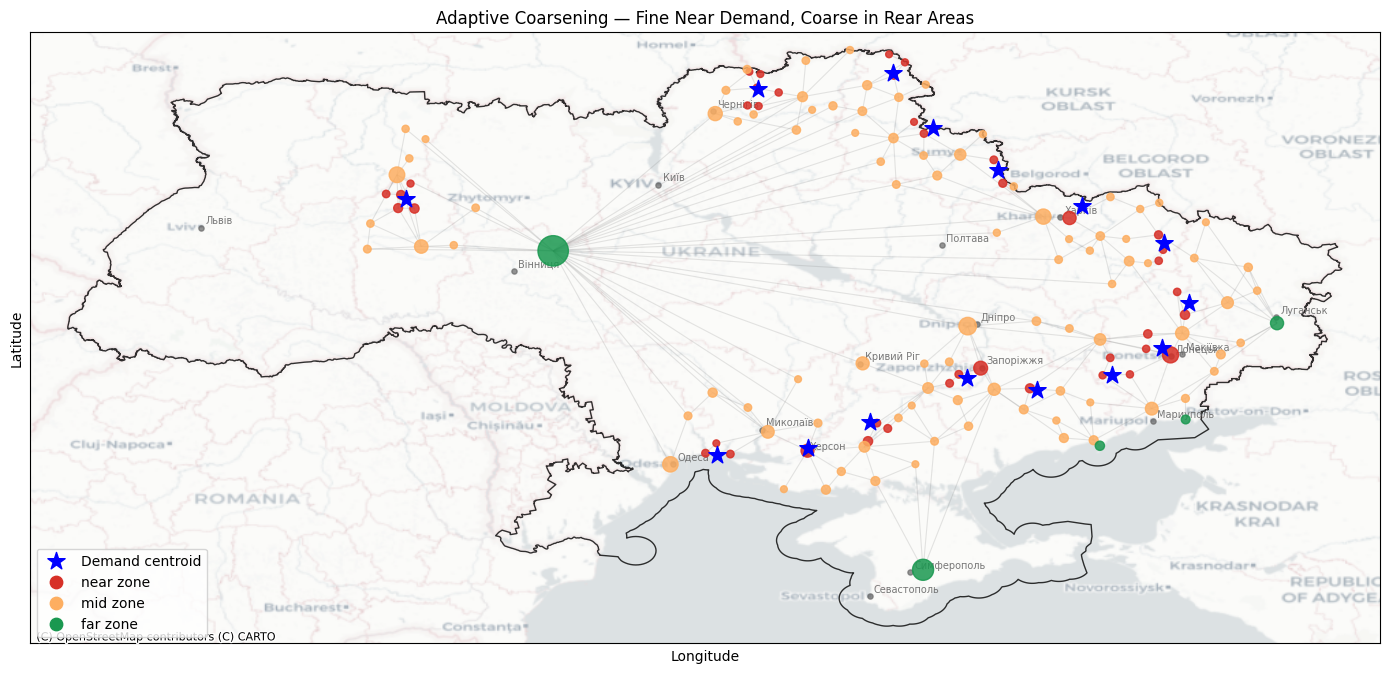

In [3]:
import contextily as ctx
from pathlib import Path
from sklearn.cluster import DBSCAN

def cluster_demand_kmedoids(coords, n_clusters, random_state=42, max_iter=8, candidate_cap=200):
    coords = np.asarray(coords, dtype=float)
    n_samples = len(coords)
    if n_samples == 0:
        raise ValueError("cluster_demand_kmedoids needs at least one point")
    if n_clusters > n_samples:
        raise ValueError("n_clusters cannot exceed the number of points")

    rng = np.random.default_rng(random_state)
    medoid_indices = [int(rng.integers(n_samples))]
    closest_dist = ((coords - coords[medoid_indices[0]]) ** 2).sum(axis=1)

    for _ in range(1, n_clusters):
        total = closest_dist.sum()
        if total <= 0:
            remaining = np.setdiff1d(np.arange(n_samples), np.array(medoid_indices), assume_unique=False)
            next_idx = int(rng.choice(remaining))
        else:
            probs = closest_dist / total
            next_idx = int(rng.choice(n_samples, p=probs))
            while next_idx in medoid_indices:
                next_idx = int(rng.choice(n_samples, p=probs))
        medoid_indices.append(next_idx)
        new_dist = ((coords - coords[next_idx]) ** 2).sum(axis=1)
        closest_dist = np.minimum(closest_dist, new_dist)

    medoid_indices = np.array(medoid_indices, dtype=int)

    for _ in range(max_iter):
        medoids = coords[medoid_indices]
        dist_to_medoids = ((coords[:, None, :] - medoids[None, :, :]) ** 2).sum(axis=2)
        labels = dist_to_medoids.argmin(axis=1)
        updated = medoid_indices.copy()

        for k in range(n_clusters):
            cluster_idx = np.where(labels == k)[0]
            if len(cluster_idx) == 0:
                fallback = int(np.argmax(np.min(dist_to_medoids, axis=1)))
                updated[k] = fallback
                continue

            cluster_points = coords[cluster_idx]
            if len(cluster_idx) > candidate_cap:
                centroid = cluster_points.mean(axis=0)
                order = np.argsort(((cluster_points - centroid) ** 2).sum(axis=1))
                near_count = min(candidate_cap // 2, len(cluster_idx))
                chosen_local = order[:near_count]
                remaining = np.setdiff1d(np.arange(len(cluster_idx)), chosen_local, assume_unique=False)
                extra_count = min(candidate_cap - len(chosen_local), len(remaining))
                if extra_count > 0:
                    extra_local = rng.choice(remaining, size=extra_count, replace=False)
                    chosen_local = np.unique(np.concatenate([chosen_local, extra_local]))
                candidate_idx = cluster_idx[chosen_local]
            else:
                candidate_idx = cluster_idx

            candidate_points = coords[candidate_idx]
            candidate_costs = ((cluster_points[:, None, :] - candidate_points[None, :, :]) ** 2).sum(axis=2).sum(axis=0)
            updated[k] = int(candidate_idx[int(np.argmin(candidate_costs))])

        if np.array_equal(updated, medoid_indices):
            break
        medoid_indices = updated

    final_medoids = coords[medoid_indices]
    final_dist = ((coords[:, None, :] - final_medoids[None, :, :]) ** 2).sum(axis=2)
    labels = final_dist.argmin(axis=1)
    return labels, medoid_indices

def build_demand_nodes_kmedoids(df, n_clusters, random_state=42, candidate_cap=200):
    working = df.copy()
    coords = working[["latitude", "longitude"]].to_numpy(dtype=float)
    labels, medoid_indices = cluster_demand_kmedoids(
        coords,
        n_clusters=n_clusters,
        random_state=random_state,
        candidate_cap=candidate_cap,
    )
    working["cluster"] = labels

    medoid_lookup = {
        cluster_id: {
            "lat": float(coords[medoid_indices[cluster_id], 0]),
            "lon": float(coords[medoid_indices[cluster_id], 1]),
        }
        for cluster_id in range(n_clusters)
    }

    demand_raw = (
        working.groupby("cluster")
        .agg(
            n_events=("event_type", "count"),
            total_fatalities=("fatalities", "sum"),
        )
        .reset_index()
    )
    demand_raw["lat"] = demand_raw["cluster"].map(lambda c: medoid_lookup[c]["lat"])
    demand_raw["lon"] = demand_raw["cluster"].map(lambda c: medoid_lookup[c]["lon"])
    demand_raw = demand_raw[["lat", "lon", "n_events", "total_fatalities"]].reset_index(drop=True)
    return working, demand_raw, medoid_indices

# ── Adaptive coarsening: finer near demand, coarser farther away ─────────
# This uses geographic distance to the demand centroids already built in the
# notebook. A network-travel-time version is also possible, but this is a
# clean first adaptive version that plugs into the current workflow.

if "demand_raw" not in globals():
    print("demand_raw not found; rebuilding demand nodes from ACLED using adaptive-cell k-medoids logic...")
    acled_path = PROJECT_ROOT / "data/ACLED Data_2026-03-25.csv"
    if not acled_path.exists():
        raise FileNotFoundError(f"Could not find ACLED data at {acled_path}")

    acled_df = pd.read_csv(acled_path)
    acled_df = acled_df[
        (acled_df["country"] == "Ukraine")
        & (acled_df["year"] >= 2022)
        & (acled_df["event_type"].isin([
            "Explosions/Remote violence",
            "Battles",
            "Violence against civilians",
        ]))
    ].copy()

    n_demand = globals().get("N_DEMAND", 15)
    acled_df, demand_raw, demand_medoid_indices = build_demand_nodes_kmedoids(
        acled_df,
        n_clusters=n_demand,
        random_state=42,
        candidate_cap=200,
    )
    print(f"Rebuilt demand_raw with {len(demand_raw)} demand nodes (k-medoids, k={n_demand}).")

def adaptive_coarsen_graph(
    G,
    demand_points,
    eps_near=0.12,
    eps_mid=0.22,
    eps_far=0.40,
    near_radius=0.18,
    mid_radius=0.55,
):
    if hasattr(demand_points, "loc"):
        demand_coords = demand_points[["lat", "lon"]].to_numpy(dtype=float)
    else:
        demand_coords = np.asarray(demand_points, dtype=float)

    if len(demand_coords) == 0:
        raise ValueError("adaptive_coarsen_graph needs at least one demand point")

    node_ids = list(G.nodes())
    coords = np.array([[G.nodes[n]["y"], G.nodes[n]["x"]] for n in node_ids], dtype=float)

    node_to_demand_dist = {}
    zone_to_nodes = {"near": [], "mid": [], "far": []}
    for i, n in enumerate(node_ids):
        dist = np.sqrt(((demand_coords - coords[i]) ** 2).sum(axis=1)).min()
        node_to_demand_dist[n] = float(dist)
        if dist <= near_radius:
            zone_to_nodes["near"].append(n)
        elif dist <= mid_radius:
            zone_to_nodes["mid"].append(n)
        else:
            zone_to_nodes["far"].append(n)

    zone_eps = {"near": eps_near, "mid": eps_mid, "far": eps_far}
    node_to_cluster = {}
    cluster_info = {}
    cluster_id = 0

    for zone in ["near", "mid", "far"]:
        zone_nodes = zone_to_nodes[zone]
        if not zone_nodes:
            continue

        zone_coords = np.array([[G.nodes[n]["y"], G.nodes[n]["x"]] for n in zone_nodes], dtype=float)
        labels = DBSCAN(eps=zone_eps[zone], min_samples=1).fit(zone_coords).labels_

        for label in sorted(set(labels)):
            members = [zone_nodes[i] for i, lab in enumerate(labels) if lab == label]
            cid = cluster_id
            cluster_id += 1

            for n in members:
                node_to_cluster[n] = cid

            cluster_info[cid] = {
                "zone": zone,
                "lat": float(np.mean([G.nodes[n]["y"] for n in members])),
                "lon": float(np.mean([G.nodes[n]["x"] for n in members])),
                "member_count": len(members),
                "mean_demand_dist": float(np.mean([node_to_demand_dist[n] for n in members])),
            }

    CG_adaptive = nx.Graph()
    for cid, attrs in cluster_info.items():
        CG_adaptive.add_node(cid, **attrs)

    for u, v, data in G.edges(data=True):
        cu, cv = node_to_cluster[u], node_to_cluster[v]
        if cu == cv:
            continue
        t = data.get("travel_time", float("inf"))
        if CG_adaptive.has_edge(cu, cv):
            if t < CG_adaptive[cu][cv]["travel_time"]:
                CG_adaptive[cu][cv]["travel_time"] = t
        else:
            CG_adaptive.add_edge(cu, cv, travel_time=t)

    CG_adaptive = CG_adaptive.subgraph(max(nx.connected_components(CG_adaptive), key=len)).copy()
    return CG_adaptive, node_to_demand_dist, zone_to_nodes

# Example configuration for the country-wide graph.
# Smaller eps near demand keeps more detail around important areas.
adaptive_params = {
    "eps_near": 0.15,
    "eps_mid": 0.20,
    "eps_far": 0.5,
    "near_radius": 0.3,
    "mid_radius": 1,
}

CG_adaptive, raw_dist_to_demand, raw_zone_membership = adaptive_coarsen_graph(
    G_raw,
    demand_raw[["lat", "lon"]],
    **adaptive_params,
)

print("Adaptive coarsening parameters:")
for k, v in adaptive_params.items():
    print(f"  {k} = {v}")

print("\nRaw-node zone counts:")
for zone in ["near", "mid", "far"]:
    print(f"  {zone}: {len(raw_zone_membership[zone])} raw nodes")

adaptive_zone_counts = pd.Series([CG_adaptive.nodes[n]["zone"] for n in CG_adaptive.nodes()]).value_counts()
print("\nAdaptive coarse-node zone counts:")
for zone in ["near", "mid", "far"]:
    print(f"  {zone}: {int(adaptive_zone_counts.get(zone, 0))} coarse nodes")

# print(f"\nUniform coarsening:  {CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges")
print(f"Adaptive coarsening: {CG_adaptive.number_of_nodes()} nodes, {CG_adaptive.number_of_edges()} edges")

# Quick visual check: near-demand areas should keep more coarse nodes.
if "ukraine_shape" not in globals():
    ukraine_shape = ox.geocode_to_gdf("Ukraine")
if "cities" not in globals():
    cities = ox.features_from_place("Ukraine", tags={"place": ["city"]}).copy()
    cities = cities[cities.geometry.geom_type == "Point"].copy()
    cities = cities[cities["name"].notna()].copy()
    if "population" in cities.columns:
        cities["population_num"] = pd.to_numeric(cities["population"], errors="coerce")
    else:
        cities["population_num"] = np.nan
    cities = cities.sort_values(["population_num", "name"], ascending=[False, True])
    cities = cities.drop_duplicates(subset="name").head(18)

zone_colors = {"near": "#d73027", "mid": "#fdae61", "far": "#1a9850"}
adaptive_pos = {n: (d["lon"], d["lat"]) for n, d in CG_adaptive.nodes(data=True)}
minx, miny, maxx, maxy = ukraine_shape.total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)
try:
    ctx.add_basemap(
        ax,
        crs="EPSG:4326",
        source=ctx.providers.CartoDB.Positron,
        zoom=6,
        alpha=0.8,
    )
except Exception as exc:
    print(f"Basemap unavailable for adaptive plot, continuing without tiles: {exc}")

ukraine_shape.boundary.plot(ax=ax, color="black", linewidth=1.0, alpha=0.8, zorder=1)
cities.plot(ax=ax, color="dimgray", markersize=14, alpha=0.7, zorder=2)
for _, city in cities.iterrows():
    ax.annotate(
        city["name"],
        (city.geometry.x, city.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=7,
        color="dimgray",
        alpha=0.9,
        zorder=3,
    )

edge_collection = nx.draw_networkx_edges(
    CG_adaptive, adaptive_pos, ax=ax, alpha=0.20, edge_color="gray", width=0.8,
)
edge_collection.set_zorder(4)

adaptive_sizes = [20 + 4 * np.sqrt(CG_adaptive.nodes[n]["member_count"]) for n in CG_adaptive.nodes()]
adaptive_colors = [zone_colors[CG_adaptive.nodes[n]["zone"]] for n in CG_adaptive.nodes()]
node_collection = nx.draw_networkx_nodes(
    CG_adaptive,
    adaptive_pos,
    ax=ax,
    node_size=adaptive_sizes,
    node_color=adaptive_colors,
    alpha=0.85,
)
node_collection.set_zorder(5)

demand_x = [row["lon"] for _, row in demand_raw.iterrows()]
demand_y = [row["lat"] for _, row in demand_raw.iterrows()]
ax.scatter(demand_x, demand_y, marker="*", c="blue", s=170, zorder=6, label="Demand centroid")

for zone in ["near", "mid", "far"]:
    ax.scatter([], [], c=zone_colors[zone], s=80, label=f"{zone} zone")

ax.set_title("Adaptive Coarsening — Fine Near Demand, Coarse in Rear Areas")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/adaptive_coarsening.png", dpi=150, bbox_inches="tight")
plt.show()

# If you want to use the adaptive graph downstream, uncomment the next line.
# CG = CG_adaptive


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import contextily as ctx

CG = CG_adaptive  # Use the adaptively coarsened graph for feature computation and visualization.

# Reuse the map layers from the Option 2 plot when available.
if "ukraine_shape" not in globals():
    ukraine_shape = ox.geocode_to_gdf("Ukraine")
if "cities" not in globals():
    cities = ox.features_from_place("Ukraine", tags={"place": ["city"]}).copy()
    cities = cities[cities.geometry.geom_type == "Point"].copy()
    cities = cities[cities["name"].notna()].copy()
    if "population" in cities.columns:
        cities["population_num"] = pd.to_numeric(cities["population"], errors="coerce")
    else:
        cities["population_num"] = np.nan
    cities = cities.sort_values(["population_num", "name"], ascending=[False, True])
    cities = cities.drop_duplicates(subset="name").head(18)

# ── Compute features for each node ───────────────────────────────────────
degree = dict(CG.degree())

print("Computing betweenness centrality (may take a moment)...")
centrality = nx.betweenness_centrality(CG, weight="travel_time", normalized=True)

# Closer to demand is treated as closer to the frontline.
def min_dist_to_demand(CG, node, demand_node_ids):
    node_lat = CG.nodes[node]["lat"]
    node_lon = CG.nodes[node]["lon"]
    dists = []
    for d in demand_node_ids:
        d_lat = CG.nodes[d]["lat"]
        d_lon = CG.nodes[d]["lon"]
        dists.append(((node_lat - d_lat)**2 + (node_lon - d_lon)**2)**0.5)
    return min(dists)

demand_node_ids = sorted(set(demand_nodes["graph_node"]))
dist_to_demand = {n: min_dist_to_demand(CG, n, demand_node_ids) for n in CG.nodes()}
member_count = {n: CG.nodes[n].get("member_count", 1) for n in CG.nodes()}

# Distance to larger infrastructure hubs.
# We treat the top quartile by member_count as "large hubs" and discount nodes
# that sit close to those bigger infrastructure clusters.
large_hub_threshold = np.quantile(list(member_count.values()), 0.75)
large_hub_ids = [n for n, m in member_count.items() if m >= large_hub_threshold]
if not large_hub_ids:
    large_hub_ids = list(CG.nodes())

def dist_to_large_hub(CG, node, large_hub_ids):
    node_lat = CG.nodes[node]["lat"]
    node_lon = CG.nodes[node]["lon"]
    dists = []
    for h in large_hub_ids:
        if h == node:
            continue
        h_lat = CG.nodes[h]["lat"]
        h_lon = CG.nodes[h]["lon"]
        base_dist = ((node_lat - h_lat)**2 + (node_lon - h_lon)**2)**0.5
        hub_scale = np.sqrt(CG.nodes[h].get("member_count", 1))
        dists.append(base_dist / hub_scale)
    if not dists:
        return 0.0
    return min(dists)

large_hub_dist = {n: dist_to_large_hub(CG, n, large_hub_ids) for n in CG.nodes()}

# ── Normalize each feature to [0, 1] ─────────────────────────────────────
def normalize(d):
    vals = np.array(list(d.values()), dtype=float)
    mn, mx = vals.min(), vals.max()
    if mx == mn:
        return {k: 0.5 for k in d}
    return {k: (float(v) - mn) / (mx - mn) for k, v in d.items()}

norm_degree = normalize(degree)
norm_centrality = normalize(centrality)
norm_dist = normalize(dist_to_demand)
norm_member = normalize(member_count)
norm_large_hub_dist = normalize(large_hub_dist)
frontline_proximity = {n: 1 - norm_dist[n] for n in CG.nodes()}
large_hub_proximity = {n: 1 - norm_large_hub_dist[n] for n in CG.nodes()}

# ── Compute aᵢ and bᵢ with the updated logic ──────────────────────────────
# aᵢ = fixed opening cost
#   high if: low degree (isolated, hard to supply)
#   high if: close to frontline (needs more fortification)
#   low if:  high member count (existing infrastructure)
#   low if:  close to other larger hubs (supporting infrastructure nearby)
#
# bᵢ = per-unit capacity cost
#   high if: close to frontline (capacity is expensive to maintain under fire)
#   low if:  high centrality (well-connected nodes are efficient to expand)
#   low if:  high member count (existing infrastructure)
#   low if:  close to other larger hubs (shared support / redundancy)
node_params = {}
for n in CG.nodes():
    a_raw = (
        0.3 * (1 - norm_degree[n])
      + 0.3 * frontline_proximity[n]
      + 0.2 * (1 - norm_member[n])
      + 0.2 * (1 - large_hub_proximity[n])
    )
    b_raw = (
        0.3 * frontline_proximity[n]
      + 0.25 * (1 - norm_centrality[n])
      + 0.25 * (1 - norm_member[n])
      + 0.2 * (1 - large_hub_proximity[n])
    )
    node_params[n] = {
        "a_i": round(1 + 9 * a_raw, 3),
        "b_i": round(1 + 9 * b_raw, 3),
    }

# ── Print summary ─────────────────────────────────────────────────────────
a_vals = [v["a_i"] for v in node_params.values()]
b_vals = [v["b_i"] for v in node_params.values()]
print(f"\naᵢ: min={min(a_vals):.2f}, mean={np.mean(a_vals):.2f}, max={max(a_vals):.2f}")
print(f"bᵢ: min={min(b_vals):.2f}, mean={np.mean(b_vals):.2f}, max={max(b_vals):.2f}")

sorted_by_a = sorted(node_params.items(), key=lambda x: x[1]["a_i"])
print(f"\nLarge hub threshold (member_count): {large_hub_threshold:.2f}")
print(f"Large hub nodes: {large_hub_ids}")
print("\nTop 5 cheapest nodes to open (lowest aᵢ):")
for n, p in sorted_by_a[:5]:
    print(
        f"  Node {n}: aᵢ={p['a_i']}, bᵢ={p['b_i']}, "
        f"lat={CG.nodes[n]['lat']:.3f}, lon={CG.nodes[n]['lon']:.3f}, "
        f"degree={degree[n]}, centrality={centrality[n]:.3f}, members={member_count[n]}, "
        f"large_hub_proximity={large_hub_proximity[n]:.3f}"
    )

# ── Visualize cost structure on the Ukraine map ──────────────────────────
pos = {n: (d["lon"], d["lat"]) for n, d in CG.nodes(data=True)}
minx, miny, maxx, maxy = ukraine_shape.total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, cost_key, title in zip(
    axes,
    ["a_i", "b_i"],
    ["aᵢ — Fixed Opening Cost", "bᵢ — Per-Unit Capacity Cost"],
):
    costs = [node_params[n][cost_key] for n in CG.nodes()]
    norm = mcolors.Normalize(vmin=min(costs), vmax=max(costs))
    cmap = cm.RdYlGn_r

    ax.set_xlim(minx - x_pad, maxx + x_pad)
    ax.set_ylim(miny - y_pad, maxy + y_pad)
    try:
        ctx.add_basemap(
            ax,
            crs="EPSG:4326",
            source=ctx.providers.CartoDB.Positron,
            zoom=6,
            alpha=0.8,
        )
    except Exception as exc:
        print(f"Basemap unavailable for {cost_key}, continuing without tiles: {exc}")

    ukraine_shape.boundary.plot(ax=ax, color="black", linewidth=1.0, alpha=0.8, zorder=1)
    cities.plot(ax=ax, color="dimgray", markersize=14, alpha=0.7, zorder=2)

    for _, city in cities.iterrows():
        ax.annotate(
            city["name"],
            (city.geometry.x, city.geometry.y),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=7,
            color="dimgray",
            alpha=0.9,
            zorder=3,
        )

    edge_collection = nx.draw_networkx_edges(
        CG, pos, ax=ax, alpha=0.22, edge_color="gray", width=0.9,
    )
    edge_collection.set_zorder(4)

    node_collection = nx.draw_networkx_nodes(
        CG, pos, ax=ax,
        node_color=costs, cmap=cmap, node_size=80,
        vmin=min(costs), vmax=max(costs),
    )
    node_collection.set_zorder(5)

    demand_x = [CG.nodes[n]["lon"] for n in demand_node_ids]
    demand_y = [CG.nodes[n]["lat"] for n in demand_node_ids]
    ax.scatter(
        demand_x, demand_y, marker="*", c="blue", s=160,
        zorder=6, label="Demand node",
    )

    plt.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax,
        label=cost_key,
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="lower left")

plt.suptitle("Node Cost Structure — Updated aᵢ and bᵢ Logic", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/cost_structure.png", dpi=150, bbox_inches="tight")
plt.show()


NameError: name 'CG' is not defined